# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [ ]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [ ]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
now = Time.now()

print("UTC:", now.utc.iso)
print("IIT Kanpur:", format_iitk(now))

UTC: 2026-09-05 06:18:46.038
IIT Kanpur: 2026-09-05 11:48:46 IST


Explanation: If we use Time.now() twice, the calls happen at slightly different times and hence output different time instants

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
height = 2396 * u.m
wavelength = 600 * u.nm
uncertainty = 5 * u.mas
cadence = 10 * u.min
frequency = 1.4 * u.GHz

print("Height:", height, "=", height.to(u.km))

frequency_from_wavelength = wavelength.to(u.THz, equivalencies=u.spectral())
print("Wavelength:", wavelength, "=", frequency_from_wavelength)

print("Coordinate uncertainty:", uncertainty, "=", uncertainty.to(u.arcsec))

print("Cadence:", cadence, "=", cadence.to(u.hour))

wavelength_from_frequency = frequency.to(u.cm, equivalencies=u.spectral())
print("Frequency:", frequency, "=", wavelength_from_frequency)

Height: 2396.0 m = 2.396 km
Wavelength: 600.0 nm = 499.6540966666666 THz
Coordinate uncertainty: 5.0 mas = 0.005 arcsec
Cadence: 10.0 min = 0.16666666666666666 h
Frequency: 1.4 GHz = 21.413747 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
planning_start = Time(START_UTC, scale="utc")

print("UTC:", planning_start.utc.iso)
print("JD:", planning_start.jd)
print("MJD:", planning_start.mjd)
print("IIT Kanpur:", format_iitk(planning_start))

later = planning_start + 2.25 * u.hour

print("Later UTC:", later.utc.iso)
print("Later IIT Kanpur:", format_iitk(later))

planning_ist_datetime = planning_start.to_datetime(timezone=IITK_TIMEZONE)
roundtrip = Time(planning_ist_datetime)
difference = abs((roundtrip - planning_start).to_value(u.s))

print("Round-trip difference:", difference, "s")
print("Less than 1 microsecond:", difference < 1e-6) # gives out true if it is less than 1us

UTC: 2026-08-30 12:00:00.000
JD: 2461283.0
MJD: 61282.5
IIT Kanpur: 2026-08-30 17:30:00 IST
Later UTC: 2026-08-30 14:15:00.000
Later IIT Kanpur: 2026-08-30 19:45:00 IST
Round-trip difference: 0.0 s
Less than 1 microsecond: True


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ra_angle = Angle(FRB_RA_J2000, unit=u.hourangle)
dec_angle = Angle(FRB_DEC_J2000, unit=u.deg)

frb_icrs = SkyCoord(
    ra=ra_angle,
    dec=dec_angle,
    frame="icrs"
)

print("RA:", frb_icrs.ra.deg, "deg")
print("Dec:", frb_icrs.dec.deg, "deg")

print(
    "RA sexagesimal:",
    frb_icrs.ra.to_string(
        unit=u.hourangle,
        sep=":",
        pad=True,
        precision=4
    )
)

print(
    "Dec sexagesimal:",
    frb_icrs.dec.to_string(
        sep=":",
        pad=True,
        alwayssign=True,
        precision=4
    )
)

assert abs(frb_icrs.ra.deg - 347.2704120833) < 1e-8
assert abs(frb_icrs.dec.deg - 48.7066410556) < 1e-8

RA: 347.27041208333327 deg
Dec: 48.70664105555556 deg
RA sexagesimal: 23:09:04.8989
Dec sexagesimal: +48:42:23.9078


Explanation: From the Earth's perspective, it takes 24 hours for the sun to cross return back to the same right ascension. Hence, the celestial sphere is divided into 24 hours of RA. Declination is similar to the latitudes on Earth. Hence, we use degrees for it.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
frb_galactic = frb_icrs.galactic

print("Galactic longitude l:", frb_galactic.l.deg, "deg")
print("Galactic latitude b:", frb_galactic.b.deg, "deg")

roundtrip_icrs = frb_galactic.icrs

roundtrip_separation = frb_icrs.separation(roundtrip_icrs)

print("Round-trip separation:", roundtrip_separation.to(u.microarcsecond))

Galactic longitude l: 106.06496077332801 deg
Galactic latitude b: -10.784176285402493 deg
Round-trip separation: 0.000310733 uarcsec


Explanation: Since the transformation is happening between two different coordinate systems, the tiny non-zero round-trip residual is due to numerical floating-point/coordinate-transformation precision

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
ecliptic_frame = BarycentricTrueEcliptic(equinox=Time("J2000"))

frb_ecliptic = frb_icrs.transform_to(ecliptic_frame)

print("Ecliptic longitude lambda:", frb_ecliptic.lon.deg, "deg")

print("Ecliptic latitude beta:", frb_ecliptic.lat.deg, "deg")

assert 0 <= frb_ecliptic.lon.deg < 360
assert -90 <= frb_ecliptic.lat.deg <= 90

roundtrip_ecliptic = frb_ecliptic.transform_to(frb_icrs.frame)

print("Round-trip separation:", frb_icrs.separation(roundtrip_ecliptic).to(u.microarcsecond))

Ecliptic longitude lambda: 14.411187650340095 deg
Ecliptic latitude beta: 48.34695843744783 deg
Round-trip separation: 0 uarcsec


Explanation: Ecliptic plane is the plane of Earth's orbit around the Sun. β is the angular distance above or below the ecliptic.

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
earlier_ra = Angle(
    EARLIER_POSITION_RA,
    unit=u.hourangle
)

earlier_dec = Angle(
    EARLIER_POSITION_DEC,
    unit=u.deg
)

earlier_position = SkyCoord(
    ra=earlier_ra,
    dec=earlier_dec,
    frame="icrs"
)

alpha1 = frb_icrs.ra.to_value(u.rad)
delta1 = frb_icrs.dec.to_value(u.rad)

alpha2 = earlier_position.ra.to_value(u.rad)
delta2 = earlier_position.dec.to_value(u.rad)

cos_theta = (np.sin(delta1) * np.sin(delta2) + np.cos(delta1) * np.cos(delta2) * np.cos(alpha2 - alpha1))

cos_theta = np.clip(cos_theta, -1.0, 1.0)

theta = np.arccos(cos_theta)

theta_arcsec = np.rad2deg(theta) * 3600
theta_mas = theta_arcsec * 1000

print("Manual separation:", theta_arcsec, "arcsec")
print("Manual separation:", theta_mas, "mas")

astropy_separation = frb_icrs.separation(earlier_position)

print("Astropy separation:", astropy_separation.to(u.arcsec))

difference = abs(theta_arcsec - astropy_separation.to_value(u.arcsec))

print("Difference:", difference, "arcsec")

Manual separation: 1.4922374490540065 arcsec
Manual separation: 1492.2374490540064 mas
Astropy separation: 1.49224 arcsec
Difference: 2.277149442564408e-06 arcsec


Note that the manual calculation and astropy calculation differ by 2.28μarcsec, which is slightly greater than 1μarcsec

# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)

print("Longitude:", gtc_location.lon)
print("Latitude:", gtc_location.lat)
print("Height:", gtc_location.height)

Longitude: -17d53m20.4s
Latitude: 28d45m28.8s
Height: 2395.9999999997463 m


Explanation: The negative longitude means the observatory lies to the west of the Greenwich meridian

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
q9_time = Time("2026-08-31T00:00:00", scale="utc")

lst = q9_time.sidereal_time("apparent", longitude=gtc_location.lon)

hour_angle = (lst - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:", q9_time.utc.iso)
print("IIT Kanpur:", format_iitk(q9_time))
print("LST:", lst.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True
))
print("Hour angle:", hour_angle.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    alwayssign=True
))

UTC: 2026-08-31 00:00:00.000
IIT Kanpur: 2026-08-31 05:30:00 IST
LST: 21:25:12.20821623
Hour angle: -01:43:52.69068377


Explanation: H = LST-RA < 0. Hence, the source is to the east of the meridian

## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
lst_grid = times.sidereal_time(
    "apparent",
    longitude=gtc_location.lon
)

hour_angles = (lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)

abs_hour_angles = np.abs(hour_angles.to_value(u.hourangle))

transit_index = np.argmin(abs_hour_angles)

transit_time = times[transit_index]
transit_lst = lst_grid[transit_index]
transit_ha = hour_angles[transit_index]

print("Sample index:", transit_index)
print("UTC:", format_utc(transit_time))
print("IIT Kanpur:", format_iitk(transit_time))
print("LST:", transit_lst.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True
))
print("Hour angle:", transit_ha.to_string(
    unit=u.hourangle,
    sep=":",
    pad=True,
    alwayssign=True
))

Sample index: 82
UTC: 2026-08-31 01:40:00 UTC
IIT Kanpur: 2026-08-31 07:10:00 IST
LST: 23:05:28.63507714
Hour angle: -00:03:36.26382286


Explanation: This is not the exact transit instant because we are only checking every 10 minutes. The actual (H=0) instant most likely falls between the sampled times.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
phi = GTC_LATITUDE_DEG * u.deg
delta = frb_icrs.dec

transit_altitude = (90 * u.deg - abs(phi - delta))
zenith_distance = (90 * u.deg - transit_altitude)

print("Predicted transit altitude:", transit_altitude)
print("Predicted zenith distance:", zenith_distance)

altaz_frame = AltAz(
    obstime=times,
    location=gtc_location,
    pressure=0 * u.hPa
)

frb_gtc_altaz = frb_icrs.transform_to(altaz_frame)
max_altitude_index = np.argmax(frb_gtc_altaz.alt)
max_altitude = frb_gtc_altaz.alt[max_altitude_index]
max_zenith_distance = (90 * u.deg - max_altitude)

print("Maximum sampled altitude:", max_altitude)
print("Maximum sampled zenith distance:", max_zenith_distance)
print("Maximum altitude sample:", max_altitude_index)

Predicted transit altitude: 70d03m04.8922s
Predicted zenith distance: 19d56m55.1078s
Maximum sampled altitude: 69d53m02.08616823s
Maximum sampled zenith distance: 20d06m57.91383177s
Maximum altitude sample: 82


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
offsets = [-12, 0, 12]

phi_rad = np.deg2rad(GTC_LATITUDE_DEG)
delta_rad = frb_icrs.dec.to_value(u.rad)

for offset in offsets:

    index = transit_index + offset
    t = times[index]

    H = hour_angles[index].to_value(u.hourangle)
    H_rad = np.deg2rad(15 * H)

    sin_h = (np.sin(phi_rad) * np.sin(delta_rad) + np.cos(phi_rad) * np.cos(delta_rad) * np.cos(H_rad))

    calculated_altitude = np.rad2deg(np.arcsin(sin_h))

    astropy_altitude = (frb_gtc_altaz.alt[index].to_value(u.deg))

    difference = (calculated_altitude - astropy_altitude)

    print("\nSample:", index)
    print("UTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print("Hour angle:", H, "hour")
    print("Calculated altitude:", calculated_altitude, "deg")
    print("Astropy altitude:", astropy_altitude, "deg")
    print("Difference:", difference, "deg")


Sample: 70
UTC: 2026-08-30 23:40:00 UTC
IST: 2026-08-31 05:10:00 IST
Hour angle: -2.065548903914298 hour
Calculated altitude: 59.031948665002126 deg
Astropy altitude: 58.78157573318759 deg
Difference: 0.2503729318145389 deg

Sample: 82
UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Hour angle: -0.06007328412845325 hour
Calculated altitude: 70.039347468167 deg
Astropy altitude: 69.8839128245073 deg
Difference: 0.15543464365968873 deg

Sample: 94
UTC: 2026-08-31 03:40:00 UTC
IST: 2026-08-31 09:10:00 IST
Hour angle: 1.945402339208293 hour
Calculated altitude: 60.063043754805115 deg
Astropy altitude: 60.16260980565783 deg
Difference: -0.0995660508527152 deg


Explanation: Before crossing the meridian, hour angle is negative and approaching zero, and altitude is increasing. At transit, hour angle is almost zero, and altitude is at its maximum. After crossing the meridian, hour angle is positive, and altitude is decreasing

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
h_min = np.deg2rad(20.0)
phi_rad = np.deg2rad(GTC_LATITUDE_DEG)
delta_rad = frb_icrs.dec.to_value(u.rad)

cos_H0 = (np.sin(h_min) - np.sin(phi_rad) * np.sin(delta_rad)) / (np.cos(phi_rad) * np.cos(delta_rad))

cos_H0 = np.clip(cos_H0, -1, 1)

H0_rad = np.arccos(cos_H0)

H0_deg = np.rad2deg(H0_rad)
H0_hours = H0_deg / 15

total_hours = 2 * H0_hours

sample_count = np.count_nonzero(frb_gtc_altaz.alt >= 20 * u.deg)

print("H0:", H0_deg, "deg")
print("H0:", H0_hours, "sidereal hours")
print("Total above 20 deg:", total_hours, "hours")
print("Grid samples above 20 deg:", sample_count)

H0: 91.92747700350239 deg
H0: 6.128498466900159 sidereal hours
Total above 20 deg: 12.256996933800318 hours
Grid samples above 20 deg: 74


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
target_airmass = (frb_gtc_altaz.secz.to_value(u.dimensionless_unscaled))

target_airmass = np.asarray(
    target_airmass,
    dtype=float
)

target_airmass[(frb_gtc_altaz.alt <= 0 * u.deg) | (~np.isfinite(target_airmass)) | (target_airmass < 1)] = np.nan

finite_airmass = target_airmass[np.isfinite(target_airmass)]

best_index = np.nanargmin(target_airmass)
best_airmass = target_airmass[best_index]

safe_count = np.count_nonzero(
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= 2.5)
)

print("Finite airmass range:",np.nanmin(target_airmass),"to", np.nanmax(target_airmass))

print("Best airmass:", best_airmass)
print("Best-airmass UTC:", format_utc(times[best_index]))
print("Best-airmass IST:", format_iitk(times[best_index]))

print("Samples with 1 <= X <= 2.5:", safe_count)

Finite airmass range: 1.0649653072737555 to 55.33845064849153
Best airmass: 1.0649653072737555
Best-airmass UTC: 2026-08-31 01:40:00 UTC
Best-airmass IST: 2026-08-31 07:10:00 IST
Samples with 1 <= X <= 2.5: 68


Explanation: Below-horizon values must not be used because airmass is meant to represent atmospheric path length. A source below the horizon is not observable, so a negative secz value has no physical meaning as an observing airmass

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
with solar_system_ephemeris.set("builtin"):
    sun = get_sun(times)
    moon = get_body("moon", times, gtc_location)
sun_altaz = sun.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

moon_altaz = moon.transform_to(
    AltAz(
        obstime=times,
        location=gtc_location,
        pressure=0 * u.hPa
    )
)

sun_altitude = sun_altaz.alt.to_value(u.deg)
moon_altitude = moon_altaz.alt.to_value(u.deg)
moon_airmass = moon_altaz.secz.to_value(u.dimensionless_unscaled)

moon_airmass = np.asarray(
    moon_airmass,
    dtype=float
)

moon_airmass[
    (moon_altitude <= 0)
    | (~np.isfinite(moon_airmass))
    | (moon_airmass < 1)
    | (moon_airmass > 3)
] = np.nan

moon_separation = (moon.separation(frb_icrs).to_value(u.deg))
sun_moon_separation = (sun.separation(moon).to_value(u.deg))

illuminated_fraction = (1 - np.cos(np.deg2rad(sun_moon_separation))) / 2

moon_label = np.full(
    len(times),
    "Unknown",
    dtype=object
)

finite = (
    np.isfinite(moon_altitude)
    & np.isfinite(moon_separation)
    & np.isfinite(illuminated_fraction)
)

# Bright first
bright = finite & (
    ((illuminated_fraction >= 0.70) & (moon_altitude > 10)) | (moon_separation <= 45)
)

moon_label[bright] = "Bright"

# Dark second
dark = finite & (
    (moon_altitude < 0)
    | ((moon_separation >= 90) & (illuminated_fraction <= 0.25))
)

moon_label[dark] = "Dark"

gray = finite & ~(bright | dark)
moon_label[gray] = "Gray"

for i in range(len(times)):
    print(
        i,
        format_utc(times[i]),
        "Sun alt =", sun_altitude[i],
        "Moon alt =", moon_altitude[i],
        "Moon X =", moon_airmass[i],
        "Moon sep =", moon_separation[i],
        "f =", illuminated_fraction[i],
        "Label =", moon_label[i]
    )

print("\nTransit sample:", transit_index)
print("Moon label at transit:", moon_label[transit_index])

 '2026-08-30T12:20:00.000' '2026-08-30T12:30:00.000'
 '2026-08-30T12:40:00.000' '2026-08-30T12:50:00.000'
 '2026-08-30T13:00:00.000' '2026-08-30T13:10:00.000'
 '2026-08-30T13:20:00.000' '2026-08-30T13:30:00.000'
 '2026-08-30T13:40:00.000' '2026-08-30T13:50:00.000'
 '2026-08-30T14:00:00.000' '2026-08-30T14:10:00.000'
 '2026-08-30T14:20:00.000' '2026-08-30T14:30:00.000'
 '2026-08-30T14:40:00.000' '2026-08-30T14:50:00.000'
 '2026-08-30T15:00:00.000' '2026-08-30T15:10:00.000'
 '2026-08-30T15:20:00.000' '2026-08-30T15:30:00.000'
 '2026-08-30T15:40:00.000' '2026-08-30T15:50:00.000'
 '2026-08-30T16:00:00.000' '2026-08-30T16:10:00.000'
 '2026-08-30T16:20:00.000' '2026-08-30T16:30:00.000'
 '2026-08-30T16:40:00.000' '2026-08-30T16:50:00.000'
 '2026-08-30T17:00:00.000' '2026-08-30T17:10:00.000'
 '2026-08-30T17:20:00.000' '2026-08-30T17:30:00.000'
 '2026-08-30T17:40:00.000' '2026-08-30T17:50:00.000'
 '2026-08-30T18:00:00.000' '2026-08-30T18:10:00.000'
 '2026-08-30T18:20:00.000' '2026-08-30T18:30:0

0 2026-08-30 12:00:00 UTC Sun alt = 63.87572648089827 Moon alt = -37.6789123158606 Moon X = nan Moon sep = 46.38224042630285 f = 0.9406682728519962 Label = Dark
1 2026-08-30 12:10:00 UTC Sun alt = 65.33320567591286 Moon alt = -39.40831941330449 Moon X = nan Moon sep = 46.368866094465616 f = 0.9403132246594132 Label = Dark
2 2026-08-30 12:20:00 UTC Sun alt = 66.64557118651372 Moon alt = -41.09130244038428 Moon X = nan Moon sep = 46.35588035265813 f = 0.9399571431775076 Label = Dark
3 2026-08-30 12:30:00 UTC Sun alt = 67.78677449002078 Moon alt = -42.722816255123135 Moon X = nan Moon sep = 46.34327124507662 f = 0.9396000288786004 Label = Dark
4 2026-08-30 12:40:00 UTC Sun alt = 68.72897930636226 Moon alt = -44.297270933667434 Moon X = nan Moon sep = 46.33102623126434 f = 0.9392418822436601 Label = Dark
5 2026-08-30 12:50:00 UTC Sun alt = 69.44458236476638 Moon alt = -45.80849837313162 Moon X = nan Moon sep = 46.319132198378625 f = 0.9388827037515641 Label = Dark
6 2026-08-30 13:00:00 UTC

## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def visibility(
    altitude,
    airmass,
    sun_altitude,
    moon_separation
):
    altitude = np.asarray(altitude)
    airmass = np.asarray(airmass)
    sun_altitude = np.asarray(sun_altitude)
    moon_separation = np.asarray(moon_separation)

    arrays = [
        altitude,
        airmass,
        sun_altitude,
        moon_separation
    ]

    if not all(arr.ndim == 1
        for arr in arrays):
        raise ValueError("All inputs must be one-dimensional.")

    if not (len(altitude)
        == len(airmass)
        == len(sun_altitude)
        == len(moon_separation)):
        raise ValueError("All inputs must have equal length.")

    return ((altitude >= 20)
        & np.isfinite(airmass)
        & (airmass >= 1)
        & (airmass <= 2.5)
        & (sun_altitude <= -18)
        & (moon_separation >= 30))

altitude_condition = (frb_gtc_altaz.alt.to_value(u.deg) >= 20)
airmass_condition = (
    np.isfinite(target_airmass)
    & (target_airmass >= 1)
    & (target_airmass <= 2.5)
)

sun_condition = sun_altitude <= -18
moon_condition = moon_separation >= 30

preferred_visibility = visibility(
    frb_gtc_altaz.alt.to_value(u.deg),
    target_airmass,
    sun_altitude,
    moon_separation
)

print("Altitude condition:",altitude_condition.sum())
print("Airmass condition:",airmass_condition.sum())
print("Sun condition:",sun_condition.sum())
print("Moon condition:",moon_condition.sum())
print("Combined condition:",preferred_visibility.sum())
print("Any observable samples:", bool(np.any(preferred_visibility)))

Altitude condition: 74
Airmass condition: 68
Sun condition: 51
Moon condition: 145
Combined condition: 51
Any observable samples: True


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
q17_times = [
    times[transit_index],
    Time(
        "2026-08-31T06:00:00",
        scale="utc"
    )
]

for t in q17_times:

    frame = AltAz(
        obstime=t,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    target = frb_icrs.transform_to(frame)

    with solar_system_ephemeris.set("builtin"):
        sun_t = get_sun(t)
        moon_t = get_body(
            "moon",
            t,
            gtc_location
        )

    sun_t_altaz = sun_t.transform_to(frame)
    moon_t_altaz = moon_t.transform_to(frame)

    altitude = target.alt.to_value(u.deg)
    airmass = target.secz.to_value(u.dimensionless_unscaled)

    if (
        altitude <= 0
        or not np.isfinite(airmass)
        or airmass < 1):
        airmass = np.nan

    sun_alt = sun_t_altaz.alt.to_value(u.deg)

    moon_sep = moon_t.separation(frb_icrs).to_value(u.deg)

    c_alt = altitude >= 20
    c_air = (np.isfinite(airmass) and 1 <= airmass <= 2.5)
    c_sun = sun_alt <= -18
    c_moon = moon_sep >= 30

    final = (c_alt and c_air and c_sun and c_moon)

    print("\nUTC:", format_utc(t))
    print("IST:", format_iitk(t))
    print("Altitude:", altitude)
    print("Airmass:", airmass)
    print("Sun altitude:", sun_alt)
    print("Moon separation:", moon_sep)

    print("Altitude pass:", c_alt)
    print("Airmass pass:", c_air)
    print("Sun pass:", c_sun)
    print("Moon pass:", c_moon)
    print("Final visibility:", final)


UTC: 2026-08-31 01:40:00 UTC
IST: 2026-08-31 07:10:00 IST
Altitude: 69.8839128245073
Airmass: 1.0649653072737555
Sun altitude: -51.95592187823629
Moon separation: 45.22675357131298
Altitude pass: True
Airmass pass: True
Sun pass: True
Moon pass: True
Final visibility: True

UTC: 2026-08-31 06:00:00 UTC
IST: 2026-08-31 11:30:00 IST
Altitude: 37.98648660695393
Airmass: 1.6247597704376868
Sun altitude: -11.282036773583792
Moon separation: 44.69814595254992
Altitude pass: True
Airmass pass: True
Sun pass: False
Moon pass: True
Final visibility: False


Explanation:
Transit alone does not guarantee observability. Because transit only tells us the maximum altitude. It says nothing about whether the Sun is down, the airmass is acceptable, or the Moon is sufficiently separated

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.


Window
UTC: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
Sample-centre duration: 8.333333333333332 hours
Best target airmass: 1.0649653072737555
Midpoint Moon label: Bright


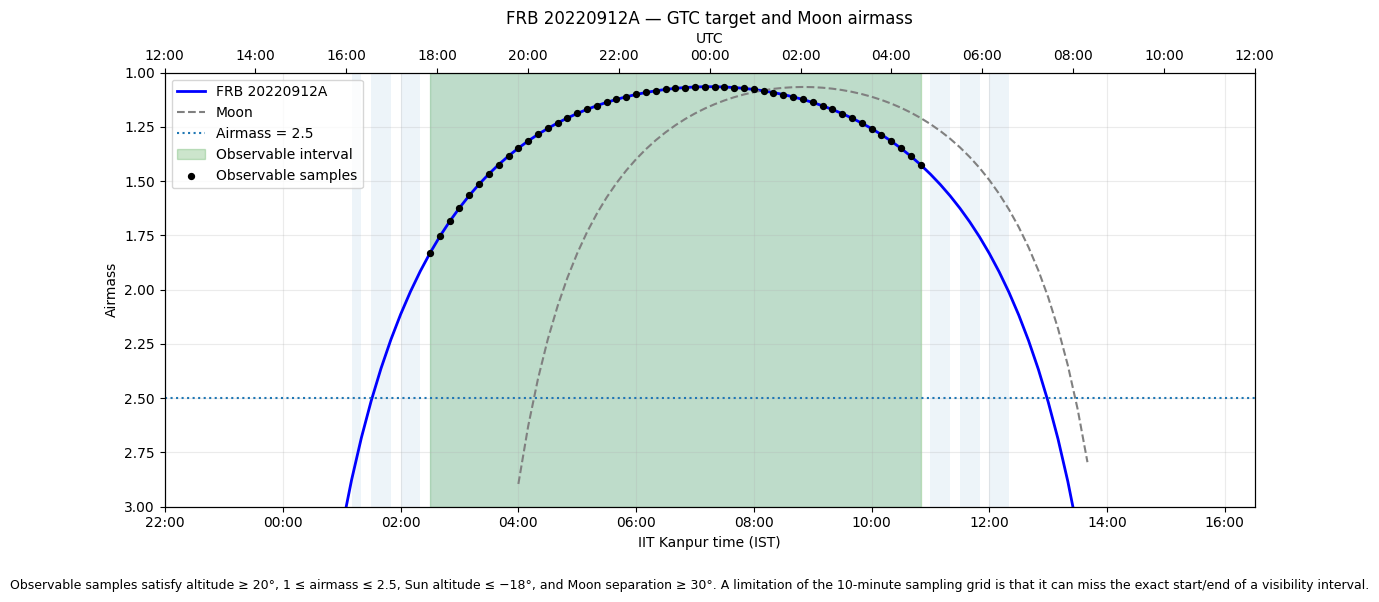

Saved: assignment_outputs/frb_20220912a_gtc_airmass.png Size: 204068 bytes


In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
def stitch_windows(times, visibility_state):

    times = np.asarray(times)
    visibility_state = np.asarray(
        visibility_state,
        dtype=bool
    )

    if times.ndim != 1:
        raise ValueError("times must be one-dimensional")

    if visibility_state.ndim != 1:
        raise ValueError("visibility_state must be one-dimensional")

    if len(times) != len(visibility_state):
        raise ValueError("times and visibility_state must have equal length")

    windows = []
    start = None

    for i, visible in enumerate(
        visibility_state
        ):
        if visible and start is None:
            start = i

        if (start is not None
            and (not visible
                or i == len(visibility_state) - 1)):
            end = (
                i
                if visible
                else i - 1)

            windows.append((times[start], times[end]))
            start = None

    return windows

windows = stitch_windows(
    times,
    preferred_visibility
)

for start, end in windows:

    indices = np.where(
        (times >= start)
        & (times <= end)
    )[0]

    best_index = indices[
        np.nanargmin(
            target_airmass[indices]
        )
    ]

    midpoint_index = indices[
        len(indices) // 2
    ]

    duration = (
        end - start
    ).to_value(u.hour)

    print("\nWindow")
    print("UTC:", format_utc(start), "to", format_utc(end))
    print("IST:", format_iitk(start), "to", format_iitk(end))

    print("Sample-centre duration:", duration, "hours")

    print("Best target airmass:", target_airmass[best_index])

    print("Midpoint Moon label:", moon_label[midpoint_index])

fig, ax = plt.subplots(figsize=(12, 6))

x = times.to_datetime(
    timezone=IITK_TIMEZONE
)

# Target airmass
ax.plot(
    x,
    target_airmass,
    color="blue",
    linewidth=2,
    label="FRB 20220912A"
)

# Moon airmass
ax.plot(
    x,
    moon_airmass,
    color="gray",
    linestyle="--",
    linewidth=1.5,
    label="Moon"
)

# Airmass limit
ax.axhline(
    2.5,
    linestyle=":",
    linewidth=1.5,
    label="Airmass = 2.5"
)

# Shade observable intervals
for start, end in windows:

    start_dt = start.to_datetime(
        timezone=IITK_TIMEZONE
    )

    end_dt = end.to_datetime(
        timezone=IITK_TIMEZONE
    )

    ax.axvspan(
        start_dt,
        end_dt,
        color="green",
        alpha=0.2,
        label="Observable interval"
    )

# Observable sample markers
visible_indices = np.where(
    preferred_visibility
)[0]

ax.scatter(
    x[visible_indices],
    target_airmass[visible_indices],
    color="black",
    s=18,
    zorder=5,
    label="Observable samples"
)

# Twilight/night background
sun_values = sun_altitude

bands = [
    (0, -6, "Day"),
    (-6, -12, "Civil/Nautical twilight"),
    (-12, -18, "Nautical/Astronomical twilight"),
    (-18, -90, "Astronomical night")
]

for upper, lower, label in bands:

    mask = (
        (sun_values <= upper)
        & (sun_values > lower)
    )

    # Shade contiguous sections
    changes = np.diff(
        mask.astype(int)
    )

    starts = np.where(changes == 1)[0] + 1
    ends = np.where(changes == -1)[0] + 1

    if mask[0]:
        starts = np.r_[0, starts]

    if mask[-1]:
        ends = np.r_[ends, len(mask)]

    for s, e in zip(starts, ends):
        ax.axvspan(
            x[s],
            x[e - 1],
            alpha=0.08
        )

ax.set_ylim(3, 1)

ax.set_ylabel(
    "Airmass"
)

ax.set_xlabel(
    "IIT Kanpur time (IST)"
)

ax.grid(
    alpha=0.25
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%H:%M",
        tz=IITK_TIMEZONE
    )
)

# UTC axis
ax_utc = ax.twiny()

ax_utc.set_xlim(
    ax.get_xlim()
)

utc_datetimes = times.to_datetime(
    timezone=timezone.utc
)

ax_utc.set_xticks(
    mdates.date2num(
        utc_datetimes[::12]
    )
)

ax_utc.set_xticklabels(
    [
        d.strftime("%H:%M")
        for d in utc_datetimes[::12]
    ]
)

ax_utc.set_xlabel(
    "UTC"
)

ax.set_title(
    "FRB 20220912A — GTC target and Moon airmass"
)

ax.legend(
    loc="upper left"
)

fig.text(
    0.5,
    0.01,
    "Observable samples satisfy altitude ≥ 20°, 1 ≤ airmass ≤ 2.5, Sun altitude ≤ −18°, and Moon separation ≥ 30°. A limitation of the 10-minute sampling grid is that it can miss the exact start/end of a visibility interval.",
    ha="center",
    fontsize=9
)

fig.tight_layout(
    rect=[0, 0.05, 1, 1]
)

output_path = (
    OUTPUT_DIR
    / "frb_20220912a_gtc_airmass.png"
)

fig.savefig(
    output_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    output_path,
    "Size:",
    output_path.stat().st_size,
    "bytes"
)

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [ ]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
q19_start = Time(
    "2026-09-01T00:00:00",
    scale="utc"
)

q19_times = (
    q19_start
    + np.arange(1440) * u.min
)

q19_frame = AltAz(
    obstime=q19_times,
    location=gtc_location,
    pressure=0 * u.hPa
)

q19_target = frb_icrs.transform_to(
    q19_frame
)

with solar_system_ephemeris.set("builtin"):
    q19_sun = get_sun(q19_times)

q19_sun_altaz = q19_sun.transform_to(
    q19_frame
)

q19_altitude = (
    q19_target.alt.to_value(u.deg)
)

q19_airmass = (
    q19_target.secz.to_value(
        u.dimensionless_unscaled
    )
)

q19_sun_altitude = (
    q19_sun_altaz.alt.to_value(u.deg)
)

q19_visible = (
    (q19_altitude > 0)
    & np.isfinite(q19_airmass)
    & (q19_airmass <= 2.5)
    & (q19_sun_altitude <= -18)
)

q19_windows = stitch_windows(
    q19_times,
    q19_visible
)

for start, end in q19_windows:

    duration = (
        end - start
    ).to_value(u.hour)

    print(
        "\nUTC:",
        format_utc(start),
        "to",
        format_utc(end)
    )

    print(
        "IST:",
        format_iitk(start),
        "to",
        format_iitk(end)
    )

    print(
        "Duration:",
        duration,
        "hours"
    )


UTC: 2026-09-01 00:00:00 UTC to 2026-09-01 05:28:00 UTC
IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:58:00 IST
Duration: 5.466666666666666 hours

UTC: 2026-09-01 20:55:00 UTC to 2026-09-01 23:59:00 UTC
IST: 2026-09-02 02:25:00 IST to 2026-09-02 05:29:00 IST
Duration: 3.0666666666666664 hours


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [34]:
# YOUR ANSWER:
# Write and run your code here. Add a Markdown cell below when an explanation is requested.
import imageio.v2 as imageio

nside = 8

npix = hp.nside2npix(nside)

theta, phi_hp = hp.pix2ang(
    nside,
    np.arange(npix)
)

dec_hp = 0.5 * np.pi - theta
ra_hp = phi_hp

ra_hp_deg = np.rad2deg(ra_hp)
dec_hp_deg = np.rad2deg(dec_hp)

start_date = Time(
    "2026-08-30T00:00:00",
    scale="utc"
)

weekly_dates = (
    start_date
    + np.arange(53) * 7 * u.day
)

weekly_dates = weekly_dates[
    weekly_dates <= (
        start_date + 365 * u.day
    )
]

print(
    "First:",
    weekly_dates[0].iso
)

print(
    "Last:",
    weekly_dates[-1].iso
)

def all_sky_visibility_map(date_time):

    sample_times = (
        date_time
        + np.arange(145) * 10 * u.min
    )

    # Local sidereal time
    lst = sample_times.sidereal_time(
        "apparent",
        longitude=gtc_location.lon
    )

    lst_rad = (
        lst.to_value(u.rad)
    )

    # Sky coordinates
    ra = ra_hp[:, None]
    dec = dec_hp[:, None]

    # Hour angle
    H = lst_rad[None, :] - ra

    # Wrap to [-pi, pi]
    H = (
        H + np.pi
    ) % (2 * np.pi) - np.pi

    lat = np.deg2rad(
        GTC_LATITUDE_DEG
    )

    # Altitude of every sky pixel
    sin_alt = (
        np.sin(lat) * np.sin(dec)
        + np.cos(lat) * np.cos(dec)
        * np.cos(H)
    )

    altitude = np.arcsin(
        np.clip(sin_alt, -1, 1)
    )

    altitude_deg = np.rad2deg(
        altitude
    )

    # Airmass approximation
    airmass = np.full_like(
        altitude_deg,
        np.nan
    )

    above = altitude_deg > 0

    airmass[above] = (
        1 / np.sin(altitude[above])
    )

    # Sun
    with solar_system_ephemeris.set(
        "builtin"
    ):

        sun = get_sun(
            sample_times
        )

    sun_frame = AltAz(
        obstime=sample_times,
        location=gtc_location,
        pressure=0 * u.hPa
    )

    sun_altaz = sun.transform_to(
        sun_frame
    )

    sun_altitude = (
        sun_altaz.alt.to_value(
            u.deg
        )
    )

    # Visibility conditions
    visible = (
        (altitude_deg >= 20)
        & np.isfinite(airmass)
        & (airmass <= 2.5)
        & (
            sun_altitude[None, :]
            <= -18
        )
    )

    # Count 10-minute samples
    visibility_hours = (
        visible.sum(axis=1)
        * 10
        / 60
    )

    return visibility_hours

frames = []

for i, date_time in enumerate(
    weekly_dates
):

    visibility_hours = (
        all_sky_visibility_map(
            date_time
        )
    )

    fig = plt.figure(
        figsize=(10, 5)
    )

    ax = fig.add_subplot(
        111,
        projection="mollweide"
    )

    longitude = (
        np.deg2rad(
            ra_hp_deg
        )
    )

    longitude = (
        (longitude + np.pi)
        % (2 * np.pi)
        - np.pi
    )

    latitude = np.deg2rad(
        dec_hp_deg
    )

    scatter = ax.scatter(
        longitude,
        latitude,
        c=visibility_hours,
        s=10
    )

    ax.grid(
        alpha=0.3
    )

    ax.set_title(
        "GTC All-Sky Visibility\n"
        + date_time.iso
    )

    cbar = plt.colorbar(
        scatter,
        ax=ax,
        pad=0.08
    )

    cbar.set_label(
        "Visibility time (hours)"
    )

    frame_path = (
        OUTPUT_DIR
        / f"gtc_visibility_{i:03d}.png"
    )

    fig.savefig(
        frame_path,
        dpi=150,
    )

    plt.close(fig)

    frames.append(
        imageio.imread(frame_path)
    )

    print(
        i,
        date_time.iso,
        frame_path
    )

gif_path = (
    OUTPUT_DIR
    / "gtc_one_year_visibility.gif"
)

imageio.mimsave(
    gif_path,
    frames,
    duration=0.4,
    loop=0
)

print(
    "Saved GIF:",
    gif_path
)

First: 2026-08-30 00:00:00.000
Last: 2027-08-29 00:00:00.000
0 2026-08-30 00:00:00.000 assignment_outputs/gtc_visibility_000.png
1 2026-09-06 00:00:00.000 assignment_outputs/gtc_visibility_001.png
2 2026-09-13 00:00:00.000 assignment_outputs/gtc_visibility_002.png
3 2026-09-20 00:00:00.000 assignment_outputs/gtc_visibility_003.png
4 2026-09-27 00:00:00.000 assignment_outputs/gtc_visibility_004.png
5 2026-10-04 00:00:00.000 assignment_outputs/gtc_visibility_005.png
6 2026-10-11 00:00:00.000 assignment_outputs/gtc_visibility_006.png
7 2026-10-18 00:00:00.000 assignment_outputs/gtc_visibility_007.png
8 2026-10-25 00:00:00.000 assignment_outputs/gtc_visibility_008.png
9 2026-11-01 00:00:00.000 assignment_outputs/gtc_visibility_009.png
10 2026-11-08 00:00:00.000 assignment_outputs/gtc_visibility_010.png
11 2026-11-15 00:00:00.000 assignment_outputs/gtc_visibility_011.png
12 2026-11-22 00:00:00.000 assignment_outputs/gtc_visibility_012.png
13 2026-11-29 00:00:00.000 assignment_outputs/gtc_vi

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
